In [7]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

from kg_pfn import Transformer, WindFarmDataset, set_seed

from wfcrl.rewards import StepPercentage
from wfcrl import environments as envs

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.transforms import Affine2D

from sklearn.model_selection import train_test_split

In [2]:
SEED = 27
set_seed(SEED)

Random seed set as 27


In [7]:
layouts = [x for x in envs.list_envs() if 'Floris' in x and 'Dec' not in x]
layouts

['Turb_TCRWP_Floris',
 'Turb3_Row1_Floris',
 'Turb6_Row2_Floris',
 'Turb16_Row5_Floris',
 'Turb32_Row5_Floris',
 'Ablaincourt_Floris',
 'HornsRev1_Floris',
 'HornsRev2_Floris',
 'Ormonde_Floris',
 'WMR_Floris',
 'Turb1_Row1_Floris',
 'Turb2_Row1_Floris',
 'Turb3_Row1_Floris',
 'Turb4_Row1_Floris',
 'Turb5_Row1_Floris',
 'Turb6_Row1_Floris',
 'Turb7_Row1_Floris',
 'Turb8_Row1_Floris',
 'Turb9_Row1_Floris',
 'Turb10_Row1_Floris',
 'Turb11_Row1_Floris',
 'Turb12_Row1_Floris']

In [3]:
df = pd.read_csv('./data/HornsRev2_Floris.csv')
df

,run_id,step,reward,yaw_0,yaw_1,yaw_2,yaw_3,yaw_4,yaw_5,yaw_6,...,power_81,power_82,power_83,power_84,power_85,power_86,power_87,power_88,power_89,power_90
0,CbmyidOk,0,2.458049,0.000000,0.000000,0.000000,-0.614936,0.000000,0.0,0.000000,...,1.517348,1.690871,1.690871,1.197996,1.160968,1.107895,0.976938,0.989387,1.690871,1.690871
1,CbmyidOk,1,2.458934,0.000000,-1.000000,0.000000,-0.614936,-1.000000,0.0,1.000000,...,1.517311,1.690871,1.690871,1.195883,1.162671,1.107472,0.976856,0.989430,1.690871,1.689502
2,CbmyidOk,2,2.459702,-0.252950,0.000000,0.000000,-0.614936,-2.000000,0.0,1.000000,...,1.517188,1.690871,1.690871,1.197580,1.169964,1.107497,0.976895,0.989136,1.690871,1.689502
3,CbmyidOk,3,2.459454,-0.252950,0.000000,0.000000,0.385064,-1.625586,0.0,1.000000,...,1.517137,1.690871,1.689502,1.197734,1.177076,1.108514,0.976718,0.996978,1.690871,1.689502
4,CbmyidOk,4,2.459868,-0.252950,0.000000,0.000000,-0.614936,-1.625586,1.0,1.000000,...,1.517062,1.690871,1.687222,1.204791,1.177049,1.108473,0.976556,1.006179,1.690871,1.689502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,dLLVzH_r,144,2.464419,-1.328351,-0.745942,-1.664548,5.000000,2.198866,4.0,5.000000,...,1.558030,1.686356,1.691302,1.187759,1.155352,1.117922,0.971679,0.980191,1.691101,1.682222
1039,dLLVzH_r,145,2.464191,-1.328351,-0.258835,-1.664548,5.000000,2.198866,4.0,5.000000,...,1.556530,1.686356,1.691302,1.191015,1.155665,1.122308,0.969382,0.978118,1.691291,1.682222
1040,dLLVzH_r,146,2.464141,-2.328351,-0.258835,-2.664548,5.000000,3.198866,4.0,5.000000,...,1.547695,1.688911,1.691302,1.188462,1.155511,1.116623,0.964944,0.978067,1.691291,1.685842
1041,dLLVzH_r,147,2.465044,-2.328351,0.741165,-1.664548,5.000000,3.198866,4.0,5.000000,...,1.546130,1.688911,1.691302,1.181579,1.155815,1.121035,0.967599,0.980144,1.691291,1.685842


In [8]:
batch_size = 128

train_runs, val_runs = train_test_split(df.run_id.unique(), train_size=0.9)

train_ds = WindFarmDataset(df[df.run_id.isin(train_runs)], num_turbines=3)
val_ds = WindFarmDataset(df[df.run_id.isin(val_runs)], scaler=train_ds.scaler, num_turbines=3)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

In [9]:
seq_len = train_ds.seq_len # episode length
n_buckets = 50 # output dist bins
input_channels = next(iter(train_loader))[0].shape[-1]
d_model = 2056
nhead = 8
ff_ratio = 4
dropout = 0.1
device='cuda'

bucket_borders = torch.linspace(-10, 10, n_buckets + 1).to(device)  # considering that y is normalized!
bucket_centers = (bucket_borders[:-1] + bucket_borders[1:]) / 2

In [13]:
model = Transformer(input_channels=input_channels, n_buckets=n_buckets, d_model=d_model, nhead=nhead, ff_ratio=ff_ratio, dropout=dropout, device=device)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(params=model.parameters(), lr=1e-4)

In [15]:
for epoch in tqdm(range(50)):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        k = torch.randint(1, seq_len, (1,)).item() # pick a random seq idx to mask from k onwards

        mask = torch.zeros(seq_len, seq_len, device=device)
        mask[:, k:] = float('-inf')
        
        optimizer.zero_grad()
        logits = model(x, mask, is_causal=False)
        bucket_idx = torch.bucketize(y, bucket_borders)[:, k]
        loss = criterion(logits[:,k,:], bucket_idx)
        loss.backward()
        optimizer.step()
    
    if epoch%5==0:
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                k = torch.randint(1, seq_len, (1,)).item()

                mask = torch.zeros(seq_len, seq_len, device=device)
                mask[:, k:] = float('-inf')

                logits = model(x, mask, is_causal=False)
                bucket_idx = torch.bucketize(y, bucket_borders)[:, k]
                loss = criterion(logits[:,k,:], bucket_idx)
                val_losses.append(loss.item())
        print(f"Val loss: {np.mean(val_losses)}")

 20%|████████▌                                  | 10/50 [00:00<00:00, 43.55it/s]

Val loss: 6.138427734375
Val loss: 2.254185914993286


 40%|█████████████████▏                         | 20/50 [00:00<00:00, 41.93it/s]

Val loss: 7.166131496429443
Val loss: 2.0080490112304688


 60%|█████████████████████████▊                 | 30/50 [00:00<00:00, 41.49it/s]

Val loss: 1.0722692012786865
Val loss: 8.16321086883545


 80%|██████████████████████████████████▍        | 40/50 [00:00<00:00, 41.30it/s]

Val loss: 2.4154813289642334
Val loss: 5.856183052062988


100%|███████████████████████████████████████████| 50/50 [00:01<00:00, 41.63it/s]

Val loss: 5.3775506019592285
Val loss: 3.2749571800231934


# Test

In [51]:
env = envs.make("Turb3_Row1_Floris", #"Ablaincourt_Floris",#
                max_num_steps=150,
                controls={"yaw": (-5, 5)},
                continuous_control = True, # continuous action space
                log=True)

/users/4/rozan012/weather-vein/wfcrl-env/wfcrl/mdp.py:203: UserWarning: No step size was provided for actuator yaw. Step size will default to 1.
  warn(


In [52]:
def ramp_and_eval(env, target_yaws, seed, options):
    obs = env.reset(seed=seed, options=options)
    r, done = 0, False
    while not done:
        delta = np.clip(target_yaws - obs['yaw'], -5, 5)
        obs, reward, term, trunc, _ = env.step({'yaw': delta})
        r += reward
        done = term or trunc
    return r[0]

In [53]:
nt = 3
options = {"wind_speed": 8, "wind_direction": 270}
scaler = train_ds.scaler

feature_cols = [f"yaw_{i}" for i in range(nt)] + ['freewind_measurements_0', 'freewind_measurements_1'] +\
                    [f"wind_speed_{i}" for i in range(nt)] + [f"wind_direction_{i}" for i in range(nt)]
x_cols = feature_cols + ['reward']  # must match what you passed to fit_transform
col_idx = {c: i for i, c in enumerate(x_cols)}

obs = env.reset(seed=SEED, options=options)

# normalize fixed features outside the loop
freewind_ws_wd = np.array([*obs['freewind_measurements'], *obs['wind_speed'], *obs['wind_direction']])
wind_cols_names = ['freewind_measurements_0', 'freewind_measurements_1'] + \
                  [f"wind_speed_{i}" for i in range(nt)] + \
                  [f"wind_direction_{i}" for i in range(nt)]
wind_idx = [col_idx[c] for c in wind_cols_names]
wind_mean = torch.tensor(scaler.mean_[wind_idx], dtype=torch.float32, device=device)
wind_scale = torch.tensor(scaler.scale_[wind_idx], dtype=torch.float32, device=device)
freewind_ws_wd_norm = (torch.tensor(freewind_ws_wd, dtype=torch.float32, device=device) - wind_mean) / wind_scale

# yaw stats (first nt columns)
yaw_mean = torch.tensor(scaler.mean_[:nt], dtype=torch.float32, device=device)
yaw_scale = torch.tensor(scaler.scale_[:nt], dtype=torch.float32, device=device)

# reward stats for denormalization
r_idx = col_idx['reward']
r_mean = scaler.mean_[r_idx]
r_scale = scaler.scale_[r_idx]

In [54]:
yaws = torch.zeros(nt, requires_grad=True, device=device)
opt = torch.optim.Adam([yaws], lr=0.1)
for _ in range(100):
    opt.zero_grad()
    yaws_norm = (yaws - yaw_mean) / yaw_scale  # keeps grad
    x_query = torch.cat([yaws_norm, freewind_ws_wd_norm]).reshape(1, 1, -1)
    logits = model(x_query)  # just the query, no context
    mean = (torch.softmax(logits, dim=-1) * bucket_centers).sum()
    (-mean).backward()
    opt.step()
    yaws.data.clamp_(-40, 40)

In [55]:
ramp_and_eval(env, yaws.detach().cpu().numpy(), SEED, options)

228.69293943370687

In [88]:
# episode_starts = [0] + list(df.index[df['step'].diff() < 0])
# x_ctx, y_ctx = [], []
# for i, start in enumerate(episode_starts):
#     end = episode_starts[i+1] if i+1 < len(episode_starts) else len(df)
#     ep = df.iloc[start:end]
#     x = torch.tensor(ep[feature_cols].values, dtype=torch.float32)
#     y = torch.tensor(ep['reward'].values, dtype=torch.float32)
#     x_ctx.append(x[:seq_len])
#     y_ctx.append(y[:seq_len])

# Visualization

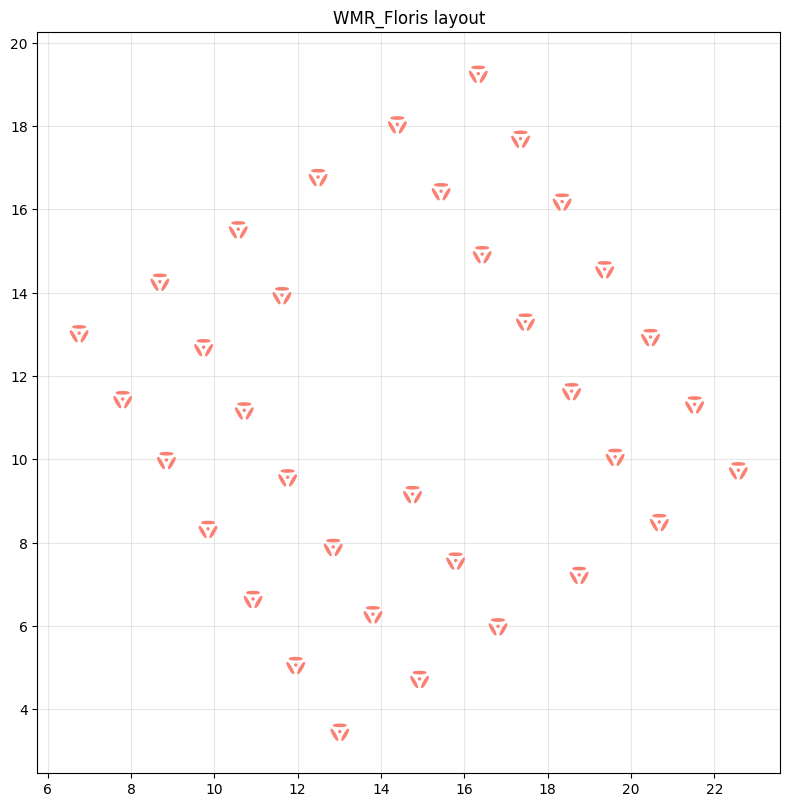

In [27]:
def draw_turbine(ax, cx, cy, size=1.0, color='salmon'):
    blade_len = size
    blade_w = size * 0.18
    # 3 blades at 0, 120, 240 degrees
    for angle_deg in [90, 210, 330]:
        angle = np.radians(angle_deg)
        # blade center offset from hub
        bx = cx + np.cos(angle) * blade_len * 0.5
        by = cy + np.sin(angle) * blade_len * 0.5
        ellipse = mpatches.Ellipse(
            (bx, by), width=blade_w, height=blade_len,
            angle=angle_deg,
            color=color, zorder=3
        )
        ax.add_patch(ellipse)
    # hub
    hub = mpatches.Circle((cx, cy), radius=size * 0.08, color=color, zorder=4)
    ax.add_patch(hub)

layout = "WMR_Floris"
env = envs.make(layout)
env.reset()
x = np.array(env.unwrapped.farm_case.xcoords)
y = np.array(env.unwrapped.farm_case.ycoords)

# normalize to readable scale
scale = 1 / 500  # adjust based on turbine spacing
x_s, y_s = x * scale, y * scale
turbine_size = 0.3

fig, ax = plt.subplots(figsize=(8, 9))
for xi, yi in zip(x_s, y_s):
    draw_turbine(ax, xi, yi, size=turbine_size, color='salmon')

ax.set_xlim(x_s.min() - 1, x_s.max() + 1)
ax.set_ylim(y_s.min() - 1, y_s.max() + 1)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(f"{layout} layout")
plt.tight_layout()
plt.show()